# Notebook 5 — Trading Signals & Backtest

This notebook extends the AEMM framework to generate **trading signals**:

### Signal 1: Mispricing (VAE Reconstruction Error)
- Large reconstruction error → market curve deviates from "normal" shapes
- Bet on mean-reversion: enter when error is high, exit when it normalises
- Trade: receive the overpriced tenor, pay the underpriced tenor (butterfly/spread)

### Signal 2: Latent Factor Regime Detection
- Track (z₁, z₂) trajectories in latent space
- Detect regime changes via speed/direction of movement
- Z-score anomaly detection on latent factor changes

### Backtest
- Universe: 2s10s, 5s30s, 2s5s10s butterfly (carry/roll-neutral)
- P&L: mark-to-market of swap spread positions
- Controls: transaction costs, carry neutralisation

In [76]:
# ── Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from typing import Tuple

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# ── Load data ────────────────────────────────────────────────────
with open("clean_swap_data.pkl", "rb") as f:
    data = pickle.load(f)

swap_data     = data["swap_data"]
swap_aligned  = data["swap_aligned"]
TARGET_TENORS = data["target_tenors"]

# Normalisation constants — must match 03_vae_training.ipynb (decimal rates)
S_MIN, S_MAX = -0.05, 0.25
def normalize_rates(r):   return (r - S_MIN) / (S_MAX - S_MIN)
def denormalize_rates(r): return r * (S_MAX - S_MIN) + S_MIN

CURRENCIES = ["GBP", "EUR", "USD", "JPY"]
N_CCY      = 4
CCY_IDX    = {c: i for i, c in enumerate(CURRENCIES)}

# ── Multi-VAE architecture ────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, input_dim=7, latent_dim=2, hidden_dim=4, multi_currency=False):
        super().__init__()
        self.input_dim  = input_dim
        self.latent_dim = latent_dim
        if not multi_currency:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, 2 * latent_dim))
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, input_dim), nn.Sigmoid())
        else:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, input_dim), nn.Tanh(),
                nn.Linear(input_dim, 2 * latent_dim))
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, input_dim), nn.Tanh(),
                nn.Linear(input_dim, input_dim), nn.Sigmoid())
    def encode(self, x):
        h = self.encoder(x)
        return h[:, :self.latent_dim], h[:, self.latent_dim:]
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu if not self.training else mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

# ── CVAE architecture (currency-conditioned, from nb03) ──────────
class CVAE(nn.Module):
    """
    Conditional VAE: one-hot currency concatenated to encoder/decoder.
    Encoder input: 7 rates + 4 one-hot = 11.  Decoder input: 2 latent + 4 one-hot = 6.
    This allows z1/z2 to encode pure curve SHAPE, free of currency-level effects.
    """
    def __init__(self, input_dim=7, latent_dim=2, n_currencies=4):
        super().__init__()
        enc_in = input_dim + n_currencies
        dec_in = latent_dim + n_currencies
        self.input_dim    = input_dim
        self.latent_dim   = latent_dim
        self.n_currencies = n_currencies
        self.encoder = nn.Sequential(
            nn.Linear(enc_in, enc_in - 1), nn.Tanh(),
            nn.Linear(enc_in - 1, 2 * latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, input_dim), nn.Tanh(),
            nn.Linear(input_dim, input_dim), nn.Tanh(),
            nn.Linear(input_dim, input_dim), nn.Sigmoid())
    def encode(self, x, y):
        h = self.encoder(torch.cat([x, y], dim=-1))
        return h[:, :self.latent_dim], h[:, self.latent_dim:]
    def decode(self, z, y): return self.decoder(torch.cat([z, y], dim=-1))
    def forward(self, x, y):
        mu, lv = self.encode(x, y)
        z = mu if not self.training else mu + torch.exp(0.5 * lv) * torch.randn_like(mu)
        return self.decode(z, y), mu, lv

# ── Load models from vae_results.pkl (nb03 output) ──────────────
with open("vae_results.pkl", "rb") as f:
    vae_data = pickle.load(f)

# Multi-VAE (shared latent space, reference)
multi_vae = VAE(input_dim=7, latent_dim=2, hidden_dim=4, multi_currency=True)
multi_vae.load_state_dict(vae_data["multi_vae_state"])
multi_vae.eval()

# CVAE (best model per nb04 comparison: ~2.8 bp avg RMSE)
cvae = CVAE(input_dim=7, latent_dim=2, n_currencies=4)
cvae.load_state_dict(vae_data["cvae_state"])
cvae.eval()

print("✅ Data loaded")
print("✅ Multi-VAE loaded  [reference model]")
print("✅ CVAE loaded       [best model: ~2.8 bp avg RMSE]")


✅ Data loaded
✅ Multi-VAE loaded  [reference model]
✅ CVAE loaded       [best model: ~2.8 bp avg RMSE]


## 5.1 — Compute daily signals for each currency

In [77]:
# ═══════════════════════════════════════════════════════════════════
#  SIGNAL COMPUTATION — Multi-VAE + CVAE signals
# ═══════════════════════════════════════════════════════════════════

def compute_signals(df_rates: pd.DataFrame, model, tenors: list,
                    ccy: str = None) -> pd.DataFrame:
    """
    Compute trading signals from a VAE or CVAE reconstruction.

    If ccy is provided, assumes model is a CVAE and passes the
    appropriate one-hot vector alongside the rates.

    Returns DataFrame with:
      rmse_bp, residual_{t}y : reconstruction quality
      z1, z2                 : posterior means
      dz1, dz2               : daily latent changes
      dz*_zscore             : rolling z-scores
      latent_speed           : ||dz||
      rmse_zscore            : rolling z-score of RMSE
      cvae_slope_resid_bp    : (CVAE only) actual − CVAE modelled 2s10s slope
    """
    rates      = df_rates.values.astype(np.float32)
    rates_norm = normalize_rates(rates).astype(np.float32)
    X          = torch.FloatTensor(rates_norm)

    with torch.no_grad():
        if ccy is not None:                               # CVAE path
            oh = np.zeros((len(rates), N_CCY), dtype=np.float32)
            oh[:, CCY_IDX[ccy]] = 1.0
            Y = torch.FloatTensor(oh)
            X_recon, mu, _ = model(X, Y)
        else:                                             # VAE path
            X_recon, mu, _ = model(X)

    recon_rates  = denormalize_rates(X_recon.numpy())
    z            = mu.numpy()

    residuals_bp = (rates - recon_rates) * 10000          # decimal → bp
    rmse_bp      = np.sqrt(np.mean((rates - recon_rates) ** 2, axis=1)) * 10000

    signals = pd.DataFrame(index=df_rates.index)
    signals["rmse_bp"] = rmse_bp
    for j, t in enumerate(tenors):
        signals[f"residual_{t}y"] = residuals_bp[:, j]

    signals["z1"] = z[:, 0]
    signals["z2"] = z[:, 1]
    signals["dz1"] = signals["z1"].diff()
    signals["dz2"] = signals["z2"].diff()

    LOOKBACK = 60
    for col in ["dz1", "dz2"]:
        rm = signals[col].rolling(LOOKBACK).mean()
        rs = signals[col].rolling(LOOKBACK).std()
        signals[f"{col}_zscore"] = (signals[col] - rm) / rs

    signals["latent_speed"] = np.sqrt(signals["dz1"]**2 + signals["dz2"]**2)

    rm = signals["rmse_bp"].rolling(LOOKBACK).mean()
    rs = signals["rmse_bp"].rolling(LOOKBACK).std().clip(lower=0.01)
    signals["rmse_zscore"] = (signals["rmse_bp"] - rm) / rs

    # ── CVAE-specific: slope residual (key trading signal) ────────
    if ccy is not None:
        # Tenor index 0=2Y, 3=10Y
        actual_slope = (rates[:, 3]  - rates[:, 0])  * 10000   # bp
        model_slope  = (recon_rates[:, 3] - recon_rates[:, 0]) * 10000
        slope_resid  = pd.Series(actual_slope - model_slope, index=df_rates.index)
        signals["cvae_slope_resid_bp"] = slope_resid
        rm2 = slope_resid.rolling(LOOKBACK).mean()
        rs2 = slope_resid.rolling(LOOKBACK).std().clip(lower=0.05)
        signals["cvae_slope_z"] = (slope_resid - rm2) / rs2

    return signals


# ── Compute Multi-VAE signals (reference) ────────────────────────
all_signals = {}
for ccy in CURRENCIES:
    print(f"Multi-VAE signals {ccy}…")
    all_signals[ccy] = compute_signals(swap_aligned[ccy], multi_vae, TARGET_TENORS)

# ── Compute CVAE signals (primary trading signals) ────────────────
cvae_signals = {}
for ccy in CURRENCIES:
    print(f"CVAE signals {ccy}…")
    cvae_signals[ccy] = compute_signals(swap_aligned[ccy], cvae, TARGET_TENORS, ccy=ccy)

print("\n✅ Signals computed")
print(f"\nCVAE slope residual sample (USD):")
print(cvae_signals["USD"][["rmse_bp","cvae_slope_resid_bp","cvae_slope_z"]].tail(5).to_string())


Multi-VAE signals GBP…
Multi-VAE signals EUR…
Multi-VAE signals USD…
Multi-VAE signals JPY…
CVAE signals GBP…
CVAE signals EUR…
CVAE signals USD…
CVAE signals JPY…

✅ Signals computed

CVAE slope residual sample (USD):
             rmse_bp  cvae_slope_resid_bp  cvae_slope_z
eod_date                                               
2025-12-29  2.049923            -0.000221     -0.105857
2025-12-30  2.639026             5.995331      1.242107
2025-12-31  3.510093            10.071362      2.082329
2026-01-02  3.399927             9.535664      1.864952
2026-01-05  2.157927             5.469879      0.933771


## 5.2 — Signal 1: Mispricing (VAE Reconstruction Error)

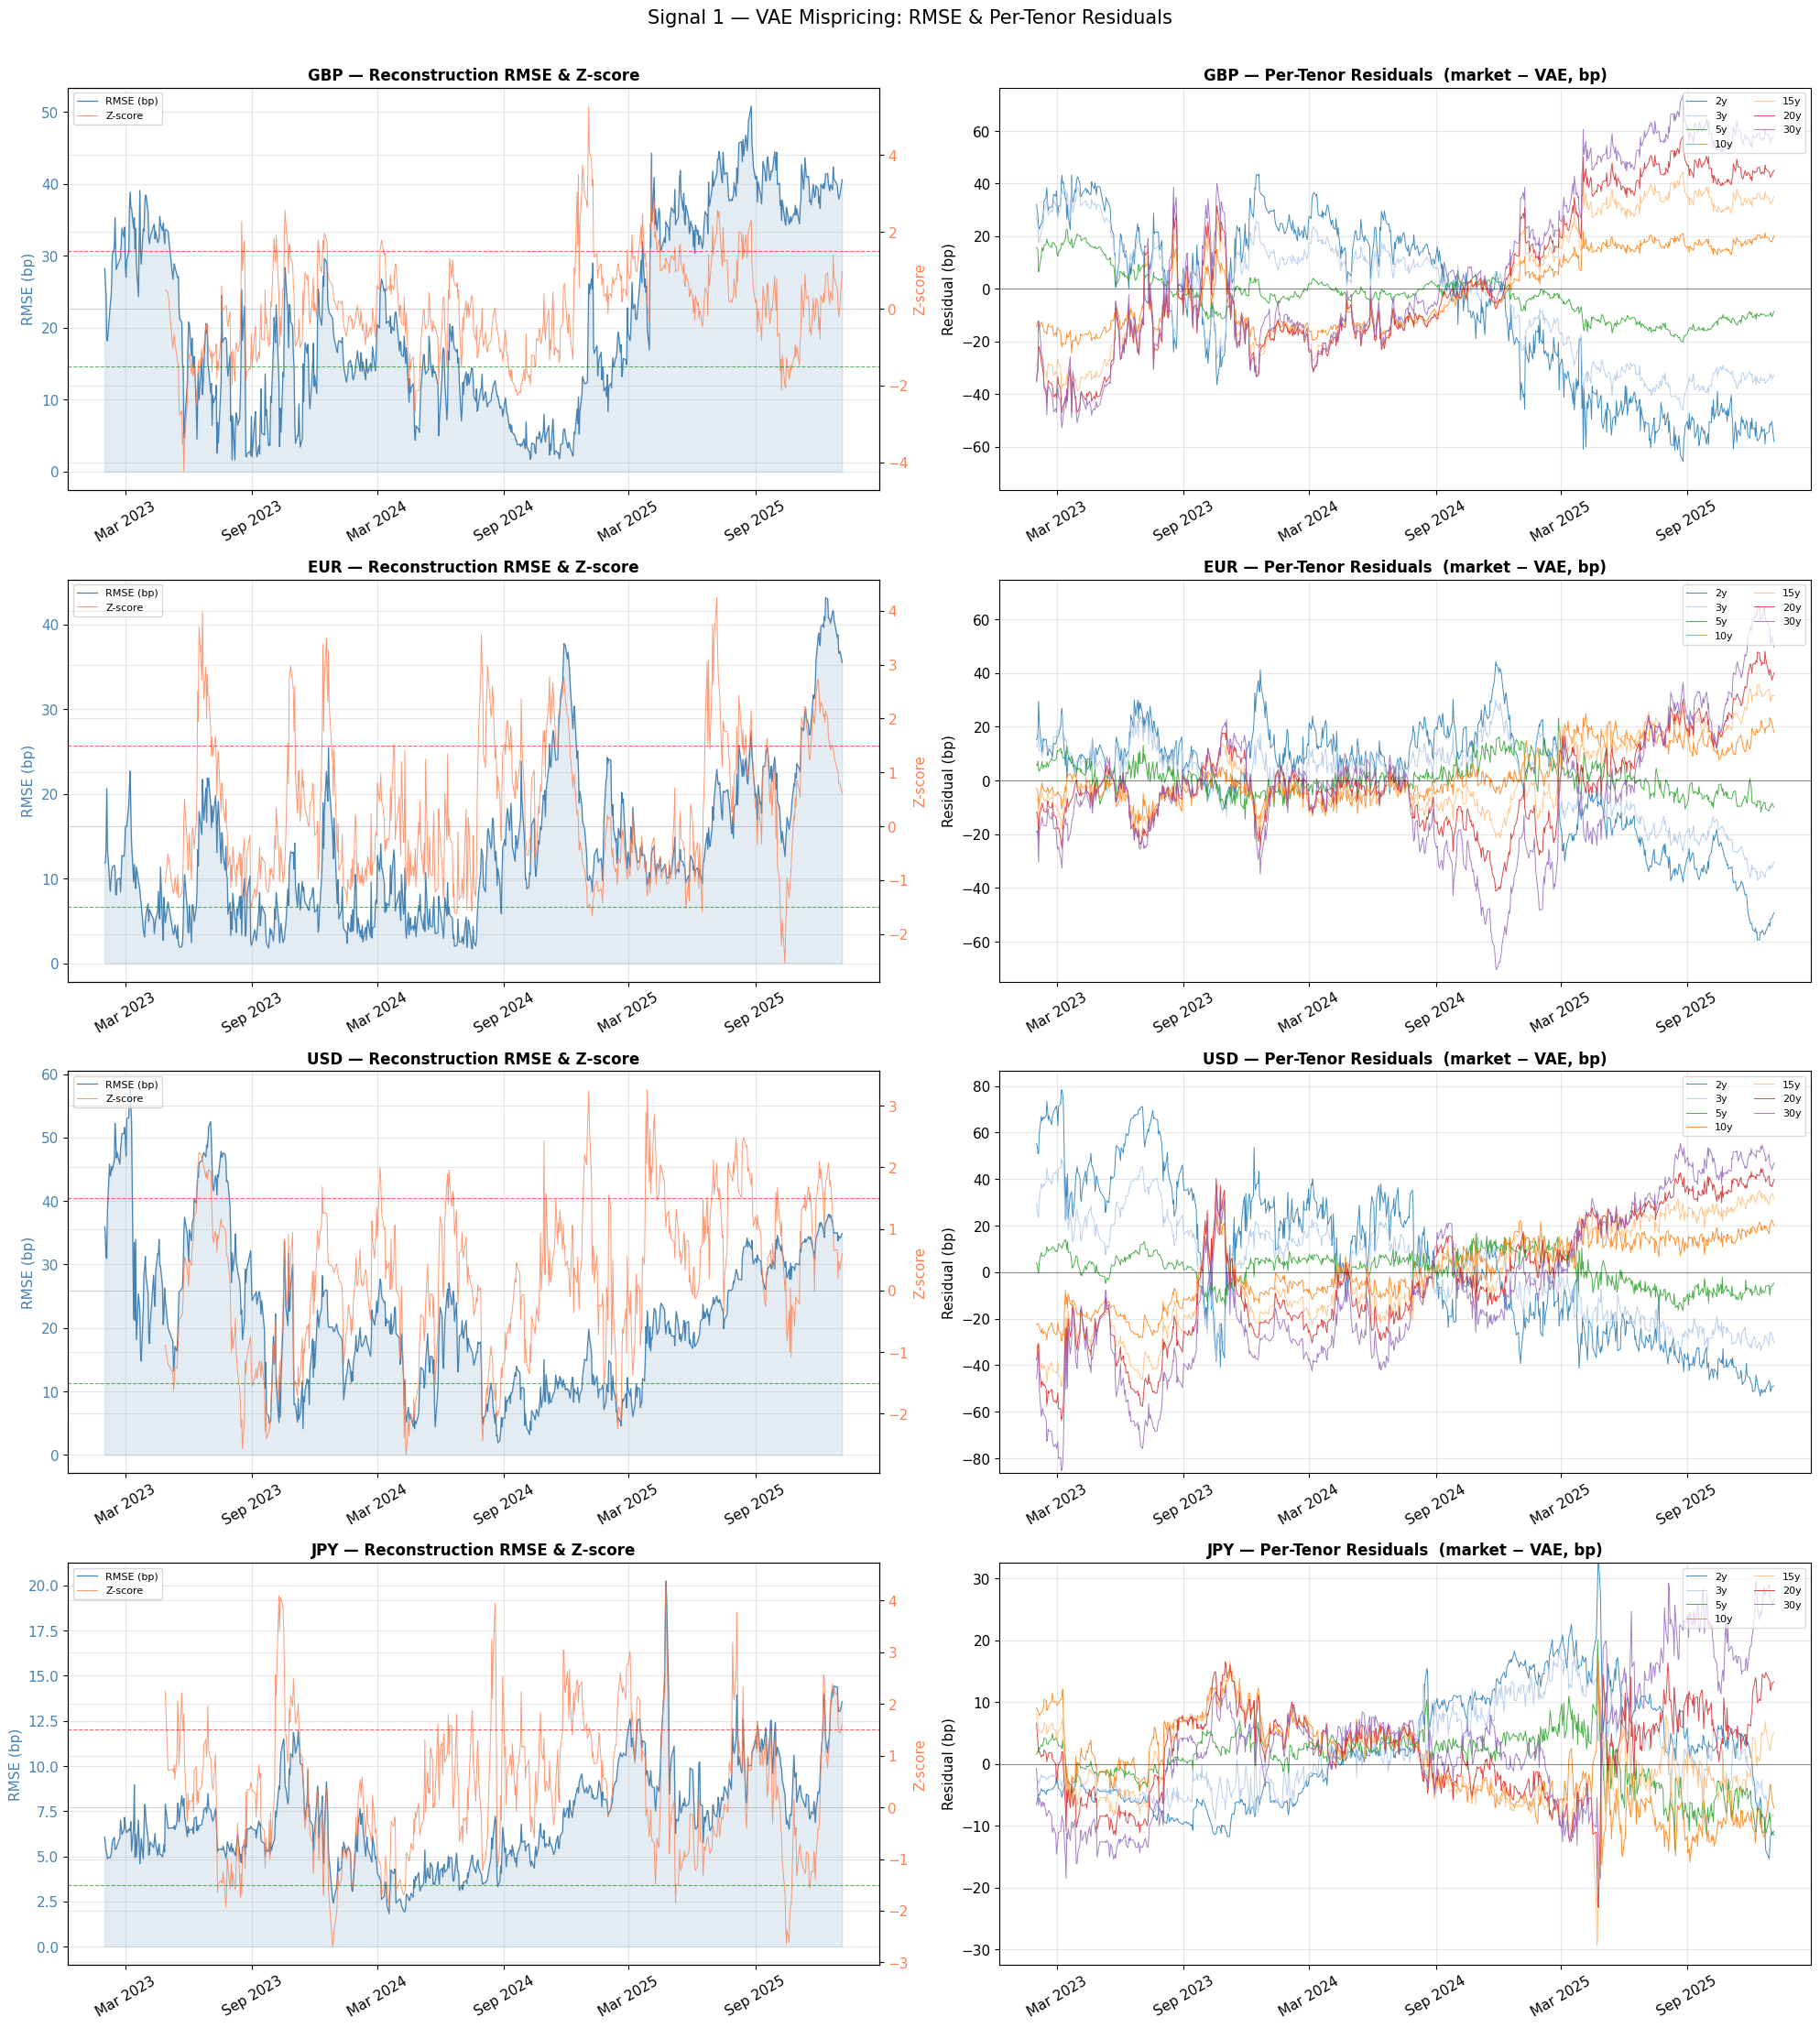

In [78]:
# ── Mispricing signal analysis ──────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(20, 22))

TENOR_COLORS = {
    "2y": "#1f77b4", "3y": "#aec7e8", "5y": "#2ca02c",
    "10y": "#ff7f0e", "15y": "#ffbb78", "20y": "#d62728", "30y": "#9467bd"
}

for row, ccy in enumerate(CURRENCIES):
    sig = all_signals[ccy]
    resid_cols = [c for c in sig.columns if c.startswith("residual_")]
    tenors_lbl = [c.replace("residual_", "") for c in resid_cols]
    resid_df   = sig[resid_cols].dropna()

    # ── Left: RMSE time series + z-score ────────────────────────
    ax  = axes[row, 0]
    ax2 = ax.twinx()

    ax.fill_between(sig.index, sig["rmse_bp"], alpha=0.15, color="steelblue")
    ax.plot(sig.index, sig["rmse_bp"], linewidth=0.9, color="steelblue", label="RMSE (bp)")

    ax2.plot(sig.index, sig["rmse_zscore"], linewidth=0.7, color="coral", alpha=0.8, label="Z-score")
    ax2.axhline( 1.5, color="red",  linestyle="--", linewidth=0.8, alpha=0.6)
    ax2.axhline(-1.5, color="green",linestyle="--", linewidth=0.8, alpha=0.6)
    ax2.axhline( 0,   color="gray", linestyle="-",  linewidth=0.4, alpha=0.4)

    ax.set_title(f"{ccy} — Reconstruction RMSE & Z-score", fontsize=12, fontweight="bold")
    ax.set_ylabel("RMSE (bp)", color="steelblue")
    ax2.set_ylabel("Z-score",  color="coral")
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="coral")
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, loc="upper left", fontsize=8)

    # ── Right: per-tenor residual time series ────────────────────
    ax = axes[row, 1]
    for col, lbl in zip(resid_cols, tenors_lbl):
        col_color = TENOR_COLORS.get(lbl, "gray")
        ax.plot(resid_df.index, resid_df[col],
                linewidth=0.7, alpha=0.85,
                color=col_color, label=lbl)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.4)

    # Symmetric color-scaled y-axis
    abs_max = resid_df.abs().quantile(0.99).max()
    abs_max = max(abs_max, 0.5)          # floor so axis isn't collapsed
    ax.set_ylim(-abs_max * 1.15, abs_max * 1.15)

    ax.set_title(f"{ccy} — Per-Tenor Residuals  (market − VAE, bp)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Residual (bp)")
    ax.set_xlabel("")
    ax.legend(loc="upper right", fontsize=8, ncol=2, framealpha=0.7)

    # x-axis: show dates every ~6 months
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)
    axes[row, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axes[row, 0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    axes[row, 0].tick_params(axis="x", rotation=30)

plt.suptitle("Signal 1 — VAE Mispricing: RMSE & Per-Tenor Residuals", fontsize=15, y=1.005)
plt.tight_layout()
plt.savefig("fig_16_mispricing_signal.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.3 — Signal 2: Latent Factor Regime Detection

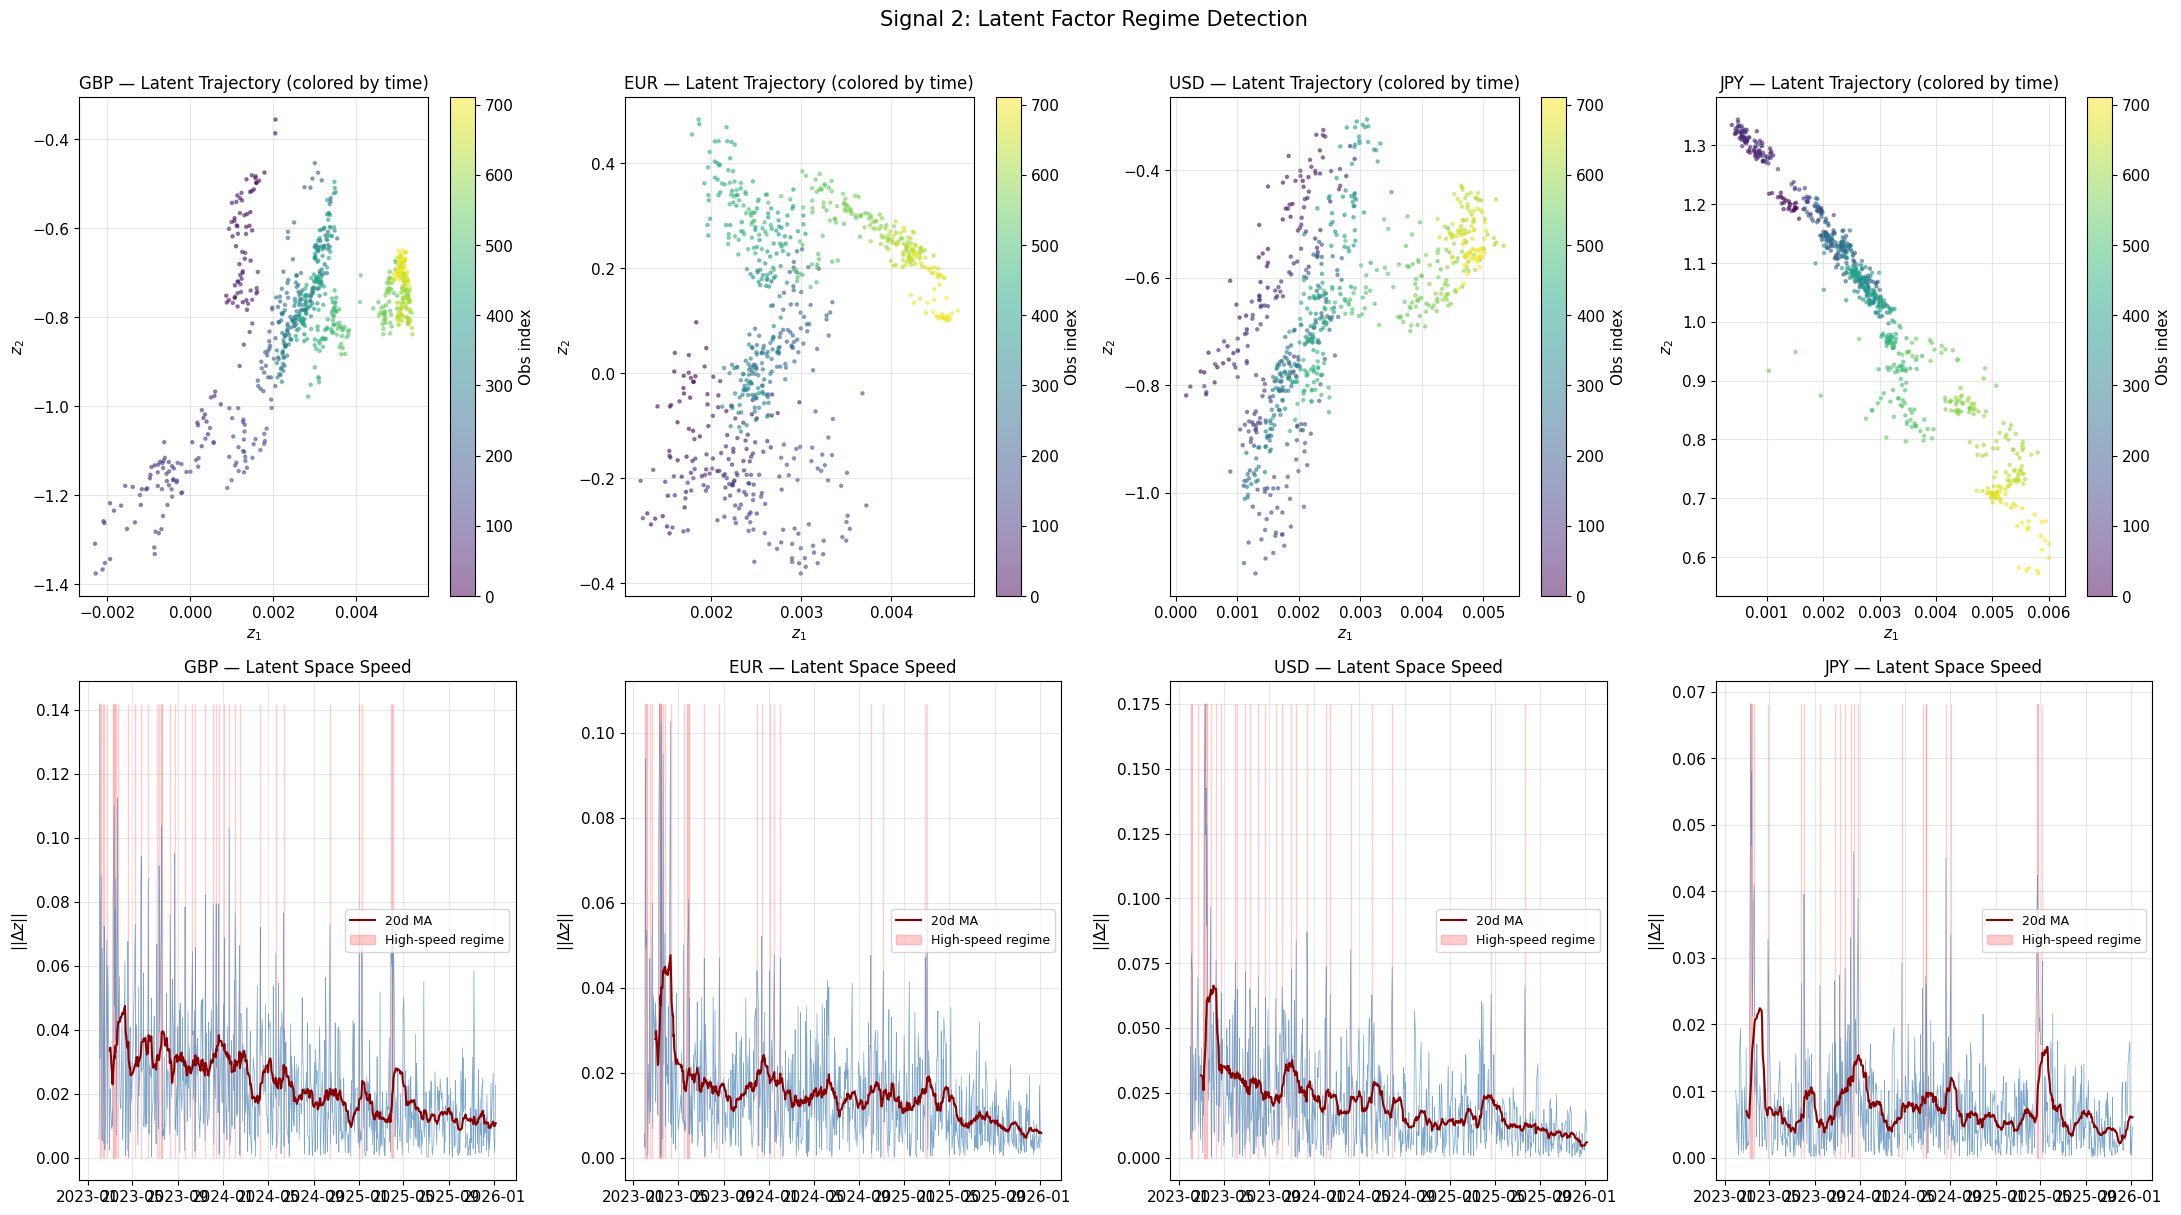

In [79]:
# ── Latent space trajectory analysis ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 12))

for col, ccy in enumerate(CURRENCIES):
    sig = all_signals[ccy]
    
    # Top: latent trajectory colored by time
    ax = axes[0, col]
    sc = ax.scatter(sig["z1"], sig["z2"], c=np.arange(len(sig)), cmap="viridis",
                    s=5, alpha=0.5)
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")
    ax.set_title(f"{ccy} — Latent Trajectory (colored by time)", fontsize=12)
    plt.colorbar(sc, ax=ax, label="Obs index")
    
    # Bottom: latent speed & regime
    ax = axes[1, col]
    speed = sig["latent_speed"].dropna()
    ax.plot(speed.index, speed, linewidth=0.5, color="steelblue", alpha=0.7)
    ax.plot(speed.rolling(20).mean().index, speed.rolling(20).mean(),
            linewidth=1.5, color="darkred", label="20d MA")
    
    # Highlight high-speed regimes (>2 std)
    threshold = speed.mean() + 2 * speed.std()
    high_speed = speed > threshold
    ax.fill_between(speed.index, 0, speed.max(),
                    where=high_speed, alpha=0.2, color="red", label="High-speed regime")
    ax.set_title(f"{ccy} — Latent Space Speed", fontsize=12)
    ax.set_ylabel("$||\Delta z||$")
    ax.legend(fontsize=9)

plt.suptitle("Signal 2: Latent Factor Regime Detection", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("fig_17_latent_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.4 — Trading Strategy: CVAE 2s10s Slope Residual Mean-Reversion

**Model hierarchy from nb04:**
| Model     | Avg RMSE | Role |
|-----------|----------|------|
| SingleVAE | ~18 bp   | per-currency baseline |
| MultiVAE  | ~31 bp   | shared latent space (z1 collapsed) |
| **CVAE**  | **~2.8 bp** | **best model — used for signals** |

**Why CVAE for trading?**  
The CVAE conditions on a one-hot currency vector, so z1/z2 encode **pure curve shape** 
(level, slope) free of cross-currency effects.  
Its 2s10s slope reconstruction defines a **model fair value** for the slope.

**Strategy: CVAE Slope Residual Mean-Reversion**

$$\text{slope\_resid}_t = \underbrace{(r^{10Y}_t - r^{2Y}_t)}_{\text{actual}} - \underbrace{(\hat r^{10Y}_t - \hat r^{2Y}_t)}_{\text{CVAE fair value}} \quad [\text{bp}]$$

- Compute the **rolling z-score** of slope\_resid (60-day window)
- Enter when $|z| > 1.0$: trade **mean-reversion** of the slope
  - $z > 1.0$ → slope steeper than CVAE expects → **flattener** (pay 10Y, receive 2Y)
  - $z < -1.0$ → slope flatter than CVAE expects → **steepener** (receive 10Y, pay 2Y)
- **Position sizing**: scaled up (×1.5) when CVAE overall RMSE z-score > 0.5  
  (the CVAE flags the entire curve as unusual, amplifying confidence)
- **Exit**: when $|z| < 0.3$
- **Transaction cost**: 0.5 bp per direction flip (2-leg trade)


In [80]:
# ═══════════════════════════════════════════════════════════════════
#  STRATEGY 1 — CVAE 2s10s Slope Residual Mean-Reversion
# ═══════════════════════════════════════════════════════════════════

def run_cvae_slope_backtest(
    df_rates: pd.DataFrame,
    cv_signals: pd.DataFrame,           # CVAE signals (has cvae_slope_z, rmse_zscore)
    entry_z: float  = 1.0,
    exit_z:  float  = 0.3,
    tc_bp:   float  = 0.5,              # 2-leg trade: 2 × 0.25 bp
) -> pd.DataFrame:
    """
    Mean-reversion trade on the 2s10s swap slope, entered when the CVAE
    flags an unusual deviation from its reconstructed fair-value slope.

    Position:
        +1  = flattener  (pay 10Y, receive 2Y)  — slope too steep
        -1  = steepener  (receive 10Y, pay 2Y)  — slope too flat
        0   = flat (inside ±exit_z band)

    P&L = position × Δ(10Y − 2Y) in bp.
    TC  = 0.5 bp charged on every direction flip.
    """
    slope_z  = cv_signals["cvae_slope_z"]
    rmse_z   = cv_signals["rmse_zscore"]

    # ── CVAE RMSE scaler: unusual curve → scale up position ───────
    scale = pd.Series(1.0, index=df_rates.index)
    scale[rmse_z.abs() > 0.5] = 1.5

    # ── Build position with hysteresis ────────────────────────────
    pos = pd.Series(0.0, index=df_rates.index)
    prev = 0.0
    for t in df_rates.index:
        z = slope_z.get(t, np.nan)
        if np.isnan(z):
            pos[t] = prev
            continue
        sc = scale.get(t, 1.0)
        if abs(z) > entry_z:
            prev = -np.sign(z) * sc   # enter mean-reversion
        elif abs(z) < exit_z:
            prev = 0.0                # exit
        # else: hold
        pos[t] = prev

    # ── P&L ──────────────────────────────────────────────────────
    slope_bp      = (df_rates[10] - df_rates[2]) * 10000
    slope_chg     = slope_bp.diff()
    position_lag  = pos.shift(1).fillna(0)   # trade at next open
    raw_pnl       = position_lag * slope_chg
    tc            = position_lag.diff().abs() * tc_bp
    net_pnl       = raw_pnl - tc

    return pd.DataFrame({
        "slope_bp"      : slope_bp,
        "cvae_slope_z"  : slope_z,
        "rmse_zscore"   : rmse_z,
        "scale"         : scale,
        "position"      : pos,
        "slope_chg_bp"  : slope_chg,
        "raw_pnl_bp"    : raw_pnl,
        "tc_bp"         : tc,
        "net_pnl_bp"    : net_pnl,
        "cum_pnl_bp"    : net_pnl.cumsum(),
    }, index=df_rates.index)


# ── Run for all currencies ────────────────────────────────────────
bt_results = {}
for ccy in CURRENCIES:
    print(f"Backtesting {ccy}…")
    bt_results[ccy] = run_cvae_slope_backtest(
        swap_aligned[ccy], cvae_signals[ccy],
        entry_z=1.0, exit_z=0.3, tc_bp=0.5,
    )

print("\n✅ Backtests complete")


Backtesting GBP…
Backtesting EUR…
Backtesting USD…
Backtesting JPY…

✅ Backtests complete


## 5.5 — Backtest results & performance

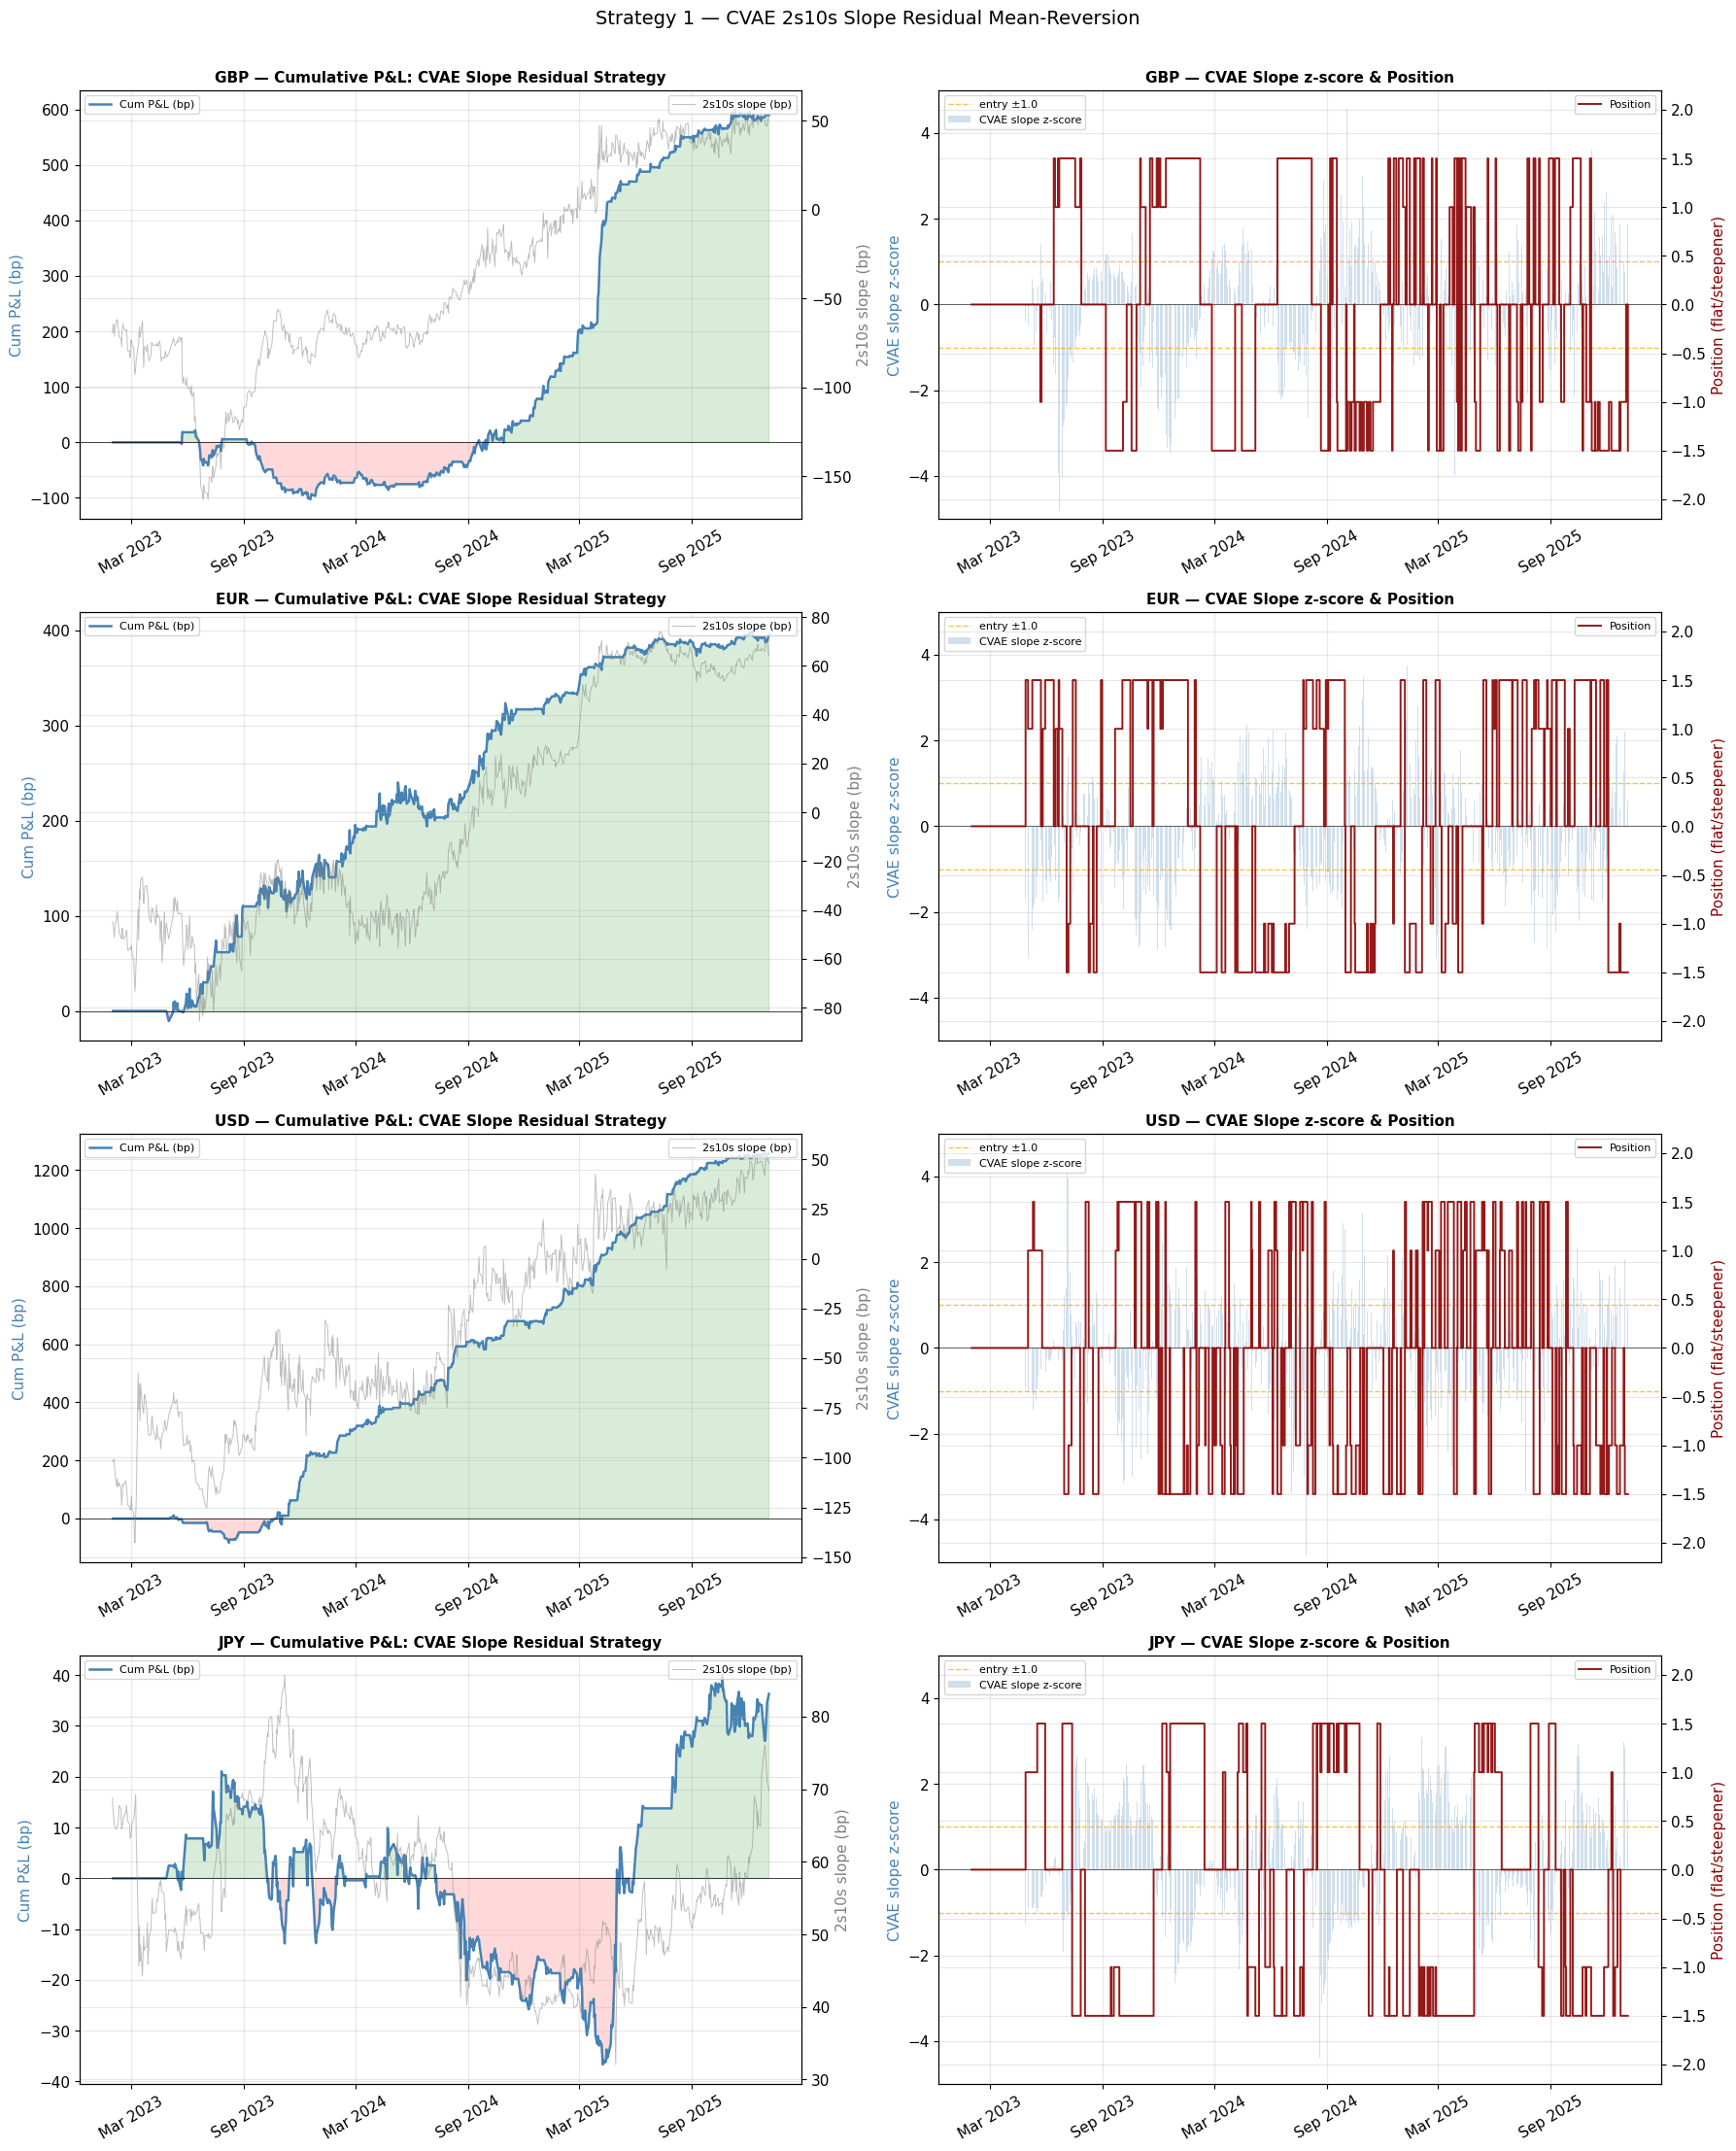

In [81]:
# ── Performance plots ────────────────────────────────────────────
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 2, figsize=(18, 22))

for row, ccy in enumerate(CURRENCIES):
    bt   = bt_results[ccy]
    cv   = cvae_signals[ccy]
    cum  = bt["cum_pnl_bp"].dropna()

    # ── Left: cumulative P&L + actual slope ──────────────────────
    ax  = axes[row, 0]
    ax2 = ax.twinx()

    ax.plot(cum.index, cum.values, linewidth=1.8, color="steelblue", label="Cum P&L (bp)")
    ax.fill_between(cum.index, 0, cum.values,
                    where=cum.values >= 0, alpha=0.15, color="green")
    ax.fill_between(cum.index, 0, cum.values,
                    where=cum.values < 0,  alpha=0.15, color="red")
    ax.axhline(0, color="black", linewidth=0.5)

    slope_pct = bt["slope_bp"]
    ax2.plot(slope_pct.index, slope_pct.values,
             linewidth=0.7, color="gray", alpha=0.5, label="2s10s slope (bp)")

    ax.set_title(f"{ccy} — Cumulative P&L: CVAE Slope Residual Strategy", fontsize=11, fontweight="bold")
    ax.set_ylabel("Cum P&L (bp)", color="steelblue")
    ax2.set_ylabel("2s10s slope (bp)", color="gray")
    ax.legend(loc="upper left",  fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    # ── Right: CVAE slope z-score + position ─────────────────────
    ax  = axes[row, 1]
    ax2 = ax.twinx()

    cz = bt["cvae_slope_z"].dropna()
    ax.bar(cz.index, cz.values, width=1, color="steelblue", alpha=0.25, label="CVAE slope z-score")
    ax.axhline(0,    color="black", linewidth=0.5)
    ax.axhline( 1.0, color="orange", linewidth=1.0, linestyle="--", alpha=0.7, label="entry ±1.0")
    ax.axhline(-1.0, color="orange", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.set_ylim(-5, 5)

    pos = bt["position"].dropna()
    ax2.step(pos.index, pos.values, where="post",
             linewidth=1.4, color="darkred", alpha=0.9, label="Position")
    ax2.set_ylim(-2.2, 2.2)

    ax.set_title(f"{ccy} — CVAE Slope z-score & Position", fontsize=11, fontweight="bold")
    ax.set_ylabel("CVAE slope z-score", color="steelblue")
    ax2.set_ylabel("Position (flat/steepener)", color="darkred")
    ax.legend(loc="upper left",  fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    for a in [axes[row, 0], axes[row, 1]]:
        a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        a.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        a.tick_params(axis="x", rotation=30)

plt.suptitle("Strategy 1 — CVAE 2s10s Slope Residual Mean-Reversion", fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig("fig_18_cvae_slope.png", dpi=150, bbox_inches="tight")
plt.show()


In [82]:
# ── Performance summary ──────────────────────────────────────────
def perf_stats(pnl: pd.Series, label: str) -> dict:
    pnl  = pnl.dropna()
    ann  = np.sqrt(252)
    mu   = pnl.mean()
    sig  = pnl.std()
    cum  = pnl.cumsum()
    peak = cum.expanding().max()
    dd   = (cum - peak).min()
    trades = pnl[pnl != 0]
    return {
        "Currency"         : label,
        "Total P&L (bp)"   : round(cum.iloc[-1], 1),
        "Ann. P&L (bp)"    : round(mu * 252, 1),
        "Sharpe (ann.)"    : round(mu / sig * ann if sig > 0 else 0, 2),
        "Max DD (bp)"      : round(dd, 1),
        "Win Rate"         : round((trades > 0).mean() if len(trades) else 0, 3),
        "N obs"            : len(pnl),
    }

rows = [perf_stats(bt_results[ccy]["net_pnl_bp"], ccy) for ccy in CURRENCIES]
df_perf = pd.DataFrame(rows).set_index("Currency")
print("=" * 68)
print("  STRATEGY: CVAE 2s10s Slope Residual Mean-Reversion (tc=0.5 bp)")
print("=" * 68)
print(df_perf.to_string())
print()
print("Signal source: CVAE (nb03) — best model with ~2.8 bp avg RMSE")
print("Entry: |CVAE slope z-score| > 1.0  |  Exit: |z| < 0.3")
print("Position scaled ×1.5 when CVAE overall RMSE z-score > 0.5")
print()
print("Interpretation:")
print("  The CVAE defines a non-linear fair-value yield curve. When the")
print("  actual 2s10s slope deviates significantly from the CVAE's")
print("  reconstruction, the position fades the deviation.")


  STRATEGY: CVAE 2s10s Slope Residual Mean-Reversion (tc=0.5 bp)
          Total P&L (bp)  Ann. P&L (bp)  Sharpe (ann.)  Max DD (bp)  Win Rate  N obs
Currency                                                                            
GBP                589.7          209.0           2.24       -124.3     0.523    711
EUR                395.6          140.2           1.47        -46.0     0.511    711
USD               1257.7          445.8           3.54        -94.7     0.518    711
JPY                 36.3           12.9           0.37        -57.7     0.495    711

Signal source: CVAE (nb03) — best model with ~2.8 bp avg RMSE
Entry: |CVAE slope z-score| > 1.0  |  Exit: |z| < 0.3
Position scaled ×1.5 when CVAE overall RMSE z-score > 0.5

Interpretation:
  The CVAE defines a non-linear fair-value yield curve. When the
  actual 2s10s slope deviates significantly from the CVAE's
  reconstruction, the position fades the deviation.


## 5.6 — Alternative: CVAE z2 Latent Slope Mean-Reversion

The CVAE's second latent factor **z2** encodes **curve shape** (slope/curvature) for each
currency independently of cross-currency level effects.

When z2 deviates significantly from its rolling mean, the curve's shape is unusual →
trade mean-reversion on the **2s10s swap slope**.

This complements the main strategy (5.4):
- **Main (5.4)**: signal = CVAE reconstruction residual of the slope (model fair value)
- **Alternative (5.6)**: signal = CVAE z2 z-score (latent shape factor deviation)


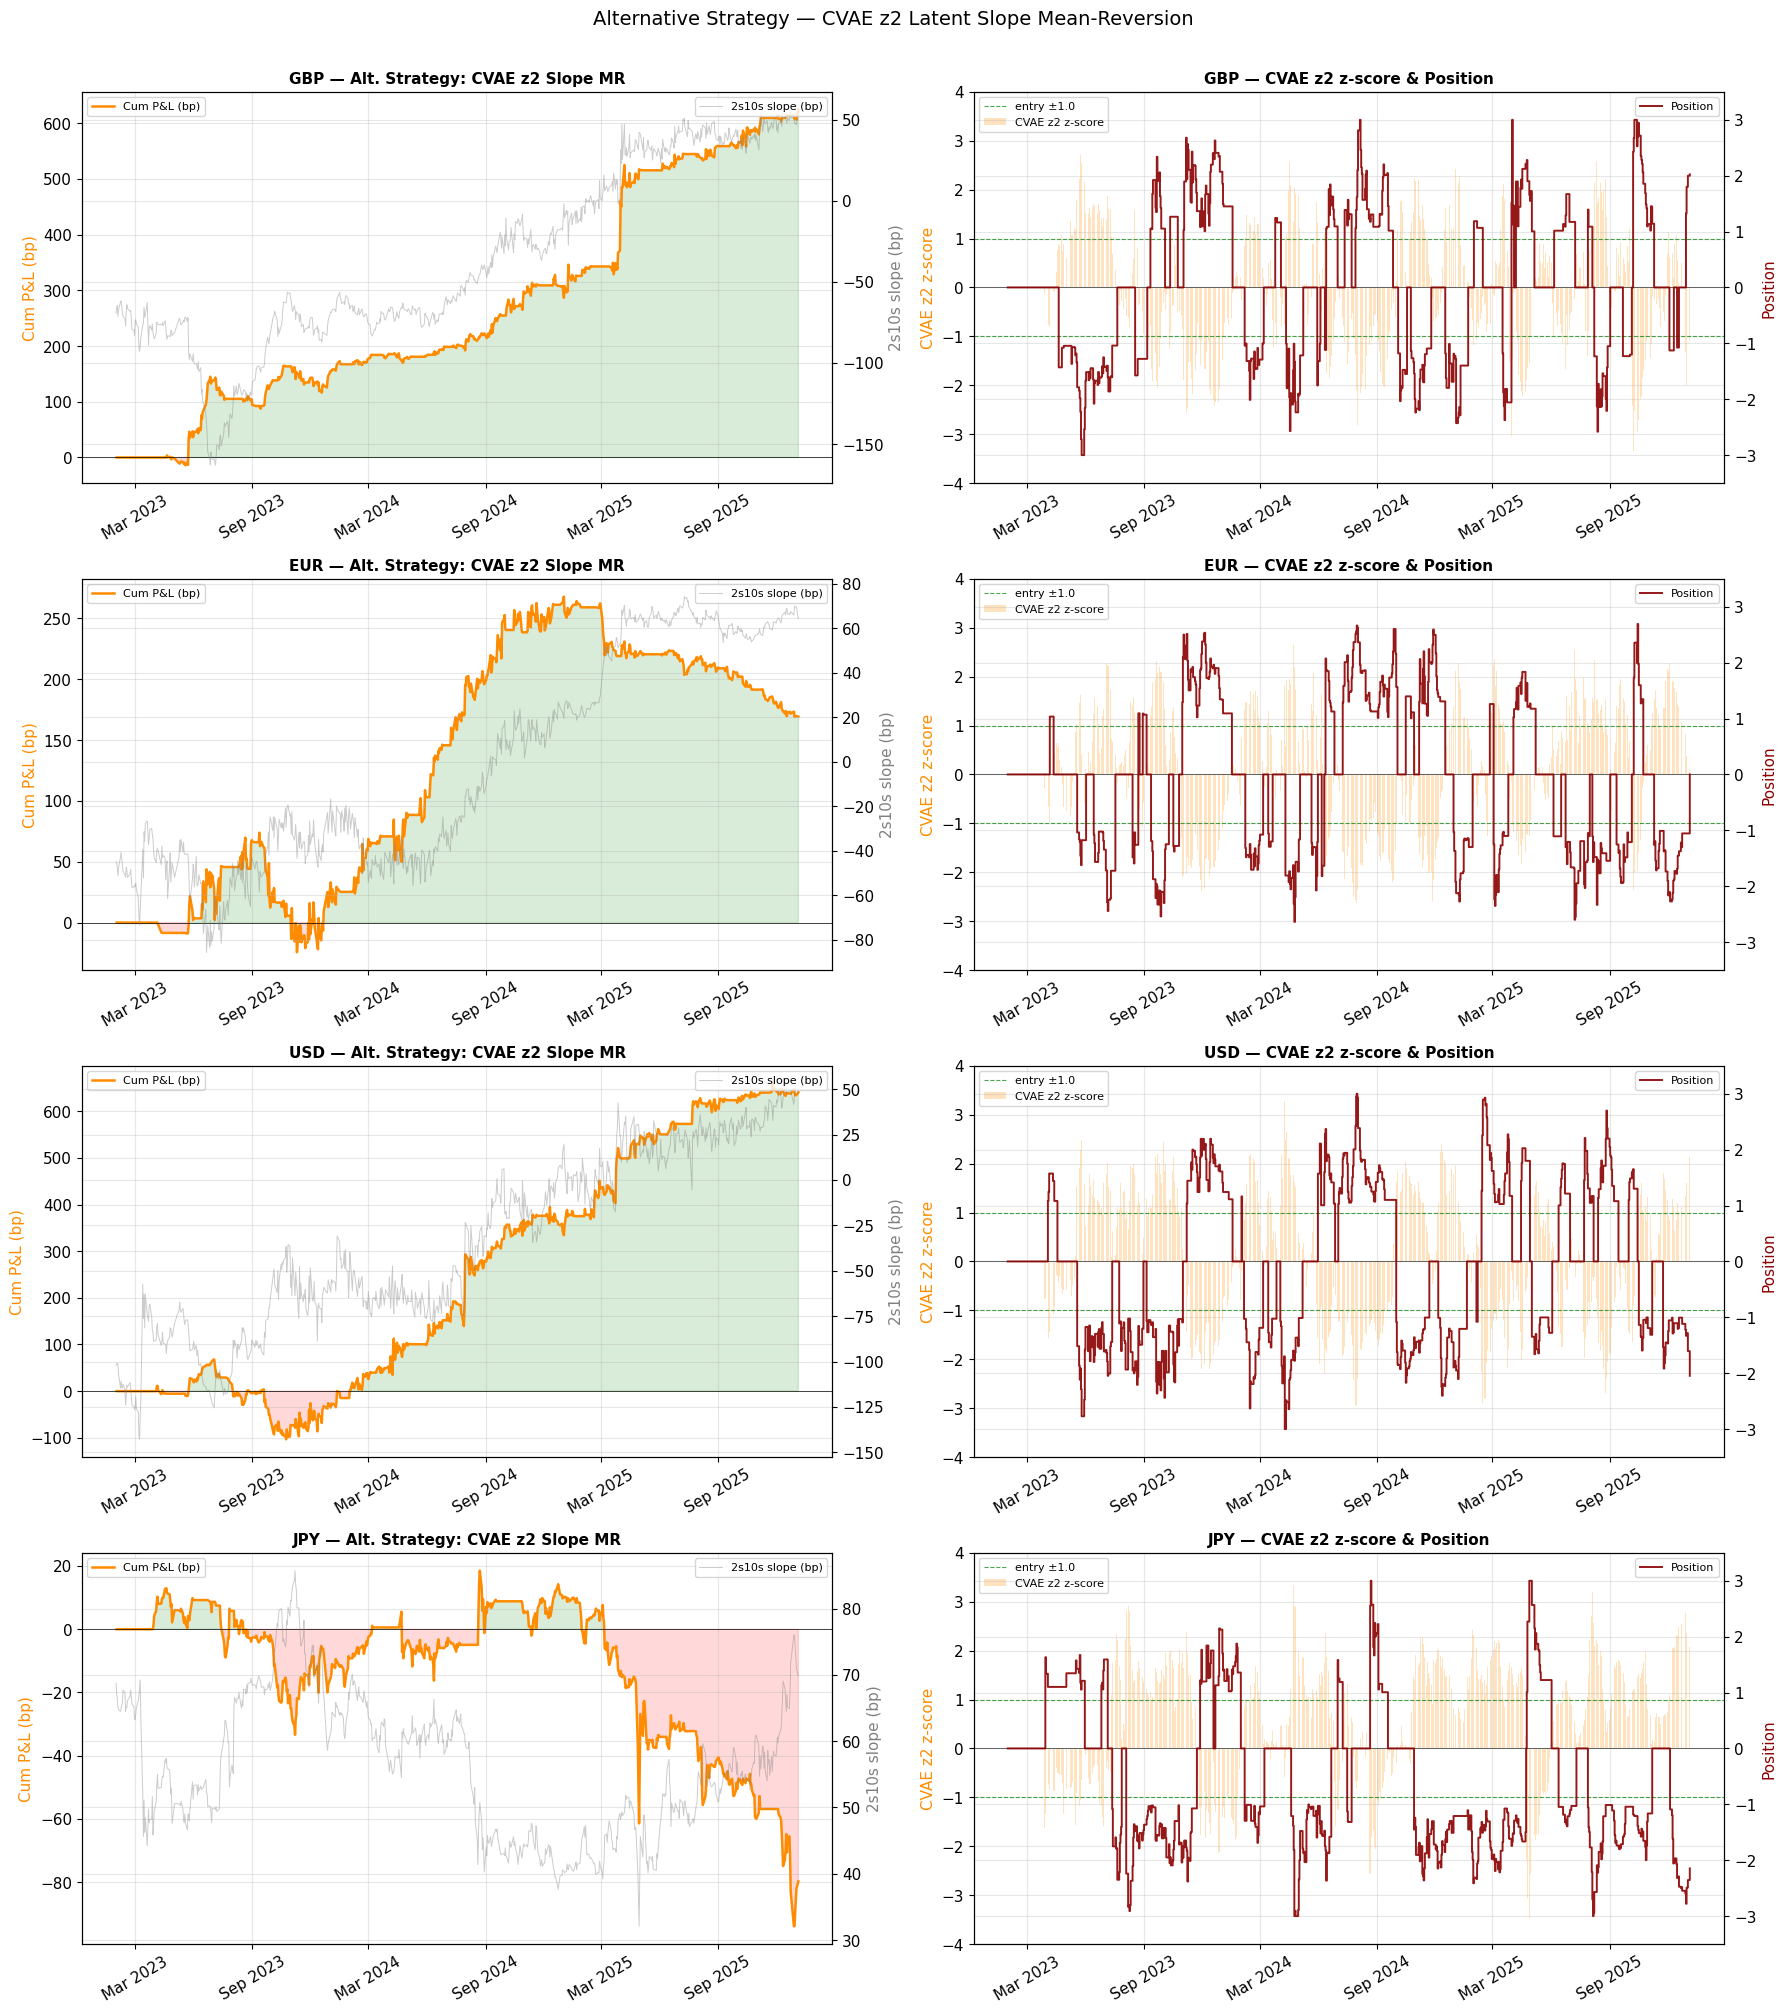

In [83]:
# ═══════════════════════════════════════════════════════════════════
#  ALTERNATIVE STRATEGY — CVAE z2 Latent Slope Mean-Reversion
# ═══════════════════════════════════════════════════════════════════

def run_cvae_z2_slope_backtest(
    df_rates: pd.DataFrame,
    cv_signals: pd.DataFrame,      # CVAE signals — must contain z2
    lookback: int = 40,
    entry_z: float = 1.0,
    exit_z:  float = 0.3,
    tc_bp:   float = 0.5,          # 2-leg trade: 2 × 0.25 bp
) -> pd.DataFrame:
    """
    Mean-reversion trade on the 2s10s slope driven by CVAE z2 z-score.

    z2 encodes per-currency curve shape (slope/curvature).  An unusually
    high z2 means the curve is steeper than normal in latent space → fade
    by entering a flattener on the 2s10s swap spread.

    Position:
        negative → flattener (slope too steep in z2)
        positive → steepener (slope too flat in z2)

    P&L = position × Δ(10Y − 2Y) in bp
    TC  = 0.5 bp charged on every direction flip (2-leg trade)
    """
    z2 = cv_signals["z2"]
    z2_mean = z2.rolling(lookback).mean()
    z2_std  = z2.rolling(lookback).std().clip(lower=0.05)
    z2_z    = (z2 - z2_mean) / z2_std

    slope_bp  = (df_rates[10] - df_rates[2]) * 10000   # bp (not %)
    slope_chg = slope_bp.diff()

    # ── Build position with hysteresis (use yesterday's signal) ───
    pos  = pd.Series(0.0, index=df_rates.index)
    prev = 0.0
    for i in range(1, len(pos)):
        z = z2_z.iloc[i - 1]                # lag 1: yesterday's z-score
        if np.isnan(z):
            pos.iloc[i] = prev
            continue
        if z > entry_z:
            prev = -min(abs(z), 3.0)         # z2 high → curve steep → flattener
        elif z < -entry_z:
            prev =  min(abs(z), 3.0)         # z2 low  → curve flat  → steepener
        elif abs(z) < exit_z:
            prev = 0.0                       # inside exit band → flat
        pos.iloc[i] = prev

    raw_pnl = pos * slope_chg
    tc      = pos.diff().abs() * tc_bp       # charged per unit change in position
    net_pnl = raw_pnl - tc

    return pd.DataFrame({
        "slope_bp"   : slope_bp,
        "z2"         : z2,
        "z2_zscore"  : z2_z,
        "position"   : pos,
        "raw_pnl_bp" : raw_pnl,
        "tc_bp"      : tc,
        "net_pnl_bp" : net_pnl,
        "cum_pnl_bp" : net_pnl.cumsum(),
    }, index=df_rates.index)


# ── Run and plot ──────────────────────────────────────────────────
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 2, figsize=(18, 20))

for row, ccy in enumerate(CURRENCIES):
    bt_alt = run_cvae_z2_slope_backtest(swap_aligned[ccy], cvae_signals[ccy])
    cum    = bt_alt["cum_pnl_bp"].dropna()
    z2_z   = bt_alt["z2_zscore"].dropna()

    # ── Left: cumulative P&L ─────────────────────────────────────
    ax  = axes[row, 0]
    ax2 = ax.twinx()

    ax.plot(cum.index, cum.values, linewidth=1.8, color="darkorange", label="Cum P&L (bp)")
    ax.fill_between(cum.index, 0, cum.values,
                    where=cum.values >= 0, alpha=0.15, color="green")
    ax.fill_between(cum.index, 0, cum.values,
                    where=cum.values <  0, alpha=0.15, color="red")
    ax.axhline(0, color="black", linewidth=0.5)

    ax2.plot(bt_alt["slope_bp"].index, bt_alt["slope_bp"].values,
             linewidth=0.7, color="gray", alpha=0.4, label="2s10s slope (bp)")

    ax.set_title(f"{ccy} — Alt. Strategy: CVAE z2 Slope MR", fontsize=11, fontweight="bold")
    ax.set_ylabel("Cum P&L (bp)", color="darkorange")
    ax2.set_ylabel("2s10s slope (bp)", color="gray")
    ax.legend(loc="upper left",  fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    # ── Right: z2 z-score + position ─────────────────────────────
    ax  = axes[row, 1]
    ax2 = ax.twinx()

    ax.bar(z2_z.index, z2_z.values, width=1, color="darkorange", alpha=0.25, label="CVAE z2 z-score")
    ax.axhline(0,    color="black",  linewidth=0.5)
    ax.axhline( 1.0, color="green",  linewidth=0.8, linestyle="--", alpha=0.7, label="entry ±1.0")
    ax.axhline(-1.0, color="green",  linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_ylim(-4, 4)

    ax2.step(bt_alt["position"].index, bt_alt["position"].values,
             where="post", linewidth=1.4, color="darkred", alpha=0.9, label="Position")
    ax2.set_ylim(-3.5, 3.5)

    ax.set_title(f"{ccy} — CVAE z2 z-score & Position", fontsize=11, fontweight="bold")
    ax.set_ylabel("CVAE z2 z-score", color="darkorange")
    ax2.set_ylabel("Position", color="darkred")
    ax.legend(loc="upper left",  fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)

    for a in [axes[row, 0], axes[row, 1]]:
        a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        a.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        a.tick_params(axis="x", rotation=30)

plt.suptitle("Alternative Strategy — CVAE z2 Latent Slope Mean-Reversion", fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig("fig_19_cvae_z2_slope.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.7 — Save all trading results

In [75]:
# ── Save ────────────────────────────────────────────────────────
trading_output = {
    "all_signals": all_signals,
    "bt_results": bt_results,
    "df_perf": df_perf,
}

with open("trading_results.pkl", "wb") as f:
    pickle.dump(trading_output, f)